# 17 · Missions: segments, the state chain, and energy allocation

A mission is what the aircraft flies: hover, climb, cruise, loiter, descent, hover. It burns fuel and battery energy and sets the fuel load and,
with reserves, the battery. `mission/segments.py` (127 lines) maps each segment to a flight condition plus a duration; `mission/mission.py`
(148 lines) chains one flight point per segment (or several) through mass and state of charge. Missions are quasi-steady: each segment is
one or a few operating points held for a duration, not a trajectory (that comes after sizing, in `trajectory/`).

The energy split per segment (`hybridization_electric`) can be prescribed or left to the optimizer: **energy allocation becomes part of the
sizing problem**, with no separate energy-management loop.

**In this notebook**
1. Segments and their flight conditions.
2. `build_mission`: the chain of points, explicitly.
3. A prescribed mission versus a semi-free one (free cruise speed and energy split) on a fixed aircraft.
4. The SOC trace and where the optimizer spends the battery.
5. Sub-segments, the equivalent-circuit pack and thermal history.
6. The Halo mission.

**Run time:** about 10 seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.mission.segments import (HoverSegment, ClimbSegment, CruiseSegment, LoiterSegment, DescentSegment,
                                               ground_distance_m)
from aircraft_closure.mission.mission import Mission, build_mission, MissionResult

## 1. Segments

| Segment | Duration | Flight condition |
|---|---|---|
| `HoverSegment(duration, altitude, h, label, ...)` | given | hover at T/W = 1 (vertical take-off and landing phases); may carry a failure state |
| `ClimbSegment(h_start, h_end, rate, V, ...)` | $\Delta h$ / rate | airplane mode at the mean altitude, with the climb rate |
| `CruiseSegment(distance, altitude, V, ...)` | distance / V | airplane mode, level |
| `LoiterSegment(duration, altitude, V, ...)` | given | airplane mode, level |
| `DescentSegment(h_start, h_end, rate, V, ...)` | $\Delta h$ / rate | airplane mode at the mean altitude, negative climb rate |

Speeds, altitudes, distances and energy splits may be Opti variables: a segment with `velocity_m_s` replaced by a variable has a free speed
(and its duration becomes an expression). `flight_condition(soc)` takes the SOC at the segment start, which is an expression from the chain.

In [2]:
from examples.mission_analysis import reference_mission, solve_mission, fuel_factor, soc_take_off, soc_minimum
mission = reference_mission()
for segment in mission.segments:
    c = segment.flight_condition(soc=0.9)
    print(f"{segment.label:<16}{type(segment).__name__:<16} {segment.duration_s():7.0f} s  ground {ground_distance_m(segment) / 1e3:6.1f} km  "
          f"mode {c.mode:<9} V {c.velocity_m_s:4.0f} m/s  h {c.altitude_m:5.0f} m  battery share {c.hybridization_electric}")

take-off hover  HoverSegment          60 s  ground    0.0 km  mode hover     V    0 m/s  h     0 m  battery share 0.7
climb           ClimbSegment         250 s  ground   12.5 km  mode airplane  V   50 m/s  h   500 m  battery share 0.0
cruise          CruiseSegment       1667 s  ground  100.0 km  mode airplane  V   60 m/s  h  1000 m  battery share 0.0
loiter          LoiterSegment       1200 s  ground   54.0 km  mode airplane  V   45 m/s  h  1000 m  battery share 0.0
descent         DescentSegment       333 s  ground   16.6 km  mode airplane  V   50 m/s  h   500 m  battery share 0.0
landing hover   HoverSegment          60 s  ground    0.0 km  mode hover     V    0 m/s  h     0 m  battery share 0.7


## 2. `build_mission`: the chain

`build_mission(opti, aircraft, aerodynamics, mission, mass_start_kg, soc_start, hybridization_electric_min=0.0, soc_floor=None, subsegments=1,
polarization_start="rest", thermal_start="steady")`. For each segment (or each of its sub-points):

In [3]:
source = inspect.getsource(build_mission)
start = source.find("    for segment, count in zip(mission.segments, counts):")
print(source[start:start + 2600])

    for segment, count in zip(mission.segments, counts):
        duration_s = segment.duration_s() if count == 1 else segment.duration_s() / count
        points = []
        for index in range(count):
            condition = segment.flight_condition(soc)
            if count > 1:
                condition = replace(condition, label=f"{condition.label} {index + 1}/{count}")
            if is_ecm:
                point = build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg,
                                           hybridization_electric_min=hybridization_electric_min,
                                           duration_s=duration_s, voltage_rc_start_V=voltage_rc_V,
                                           temperature_start_C=temperatures_C)
            else:
                point = build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg,
                                           hybridization_electric_min=hybridization_electric_min,
                      

In words, for point $k$ of duration $\Delta t_k$:

$$\text{point}_k = \texttt{build\_flight\_point}(\ldots,\ m_k,\ s_k),\qquad m_{k+1} = m_k - \dot m_{f,k}\,\Delta t_k,$$

$$s_{k+1} = \begin{cases} s_k - V_\text{oc} I_k \Delta t_k / E & \text{constant battery (chemical energy over capacity)}\\ \texttt{soc\_next} & \text{equivalent circuit (coulomb counting, mid-interval OCV)}\end{cases}$$

and $s_\text{lower} \le s_{k+1} \le s_\text{max}$ at **every** segment end, so the mission cannot dip below the floor and recharge later. With the
equivalent circuit, the RC voltages propagate from point to point and each point adds a margin on its end-of-interval voltage; with thermal models,
component temperatures propagate the same way. Fuel and battery energy are summed into a `MissionResult`. Mission-level constraints (fuel sufficiency,
final SOC, closure) are left to the caller.

The state chain is **explicit forward substitution**, not a variable per state: $m_{k+1}$ and $s_{k+1}$ are expressions of the earlier points'
variables. Every point's mass depends on all the fuel burnt before it, and IPOPT sees those dependencies exactly.

## 3. Prescribed versus semi-free

`examples/mission_analysis.py` flies the reference mission on a fixed aircraft (the tutorial 12 layout with tutorial 14's tails and the default
powertrain). Take-off mass, fuel load and wing position close with the mission: fuel load = 1.1 × fuel burnt, final SOC ≥ 0.3, hover pitch trim,
every margin ≥ 0. The objective is minimum fuel.

- **Prescribed:** hovers at 70 % battery share, everything else 0, all speeds fixed. The solver only picks rotor speeds.
- **Semi-free:** cruise speed and every segment's energy split are variables.

In [4]:
print(inspect.getsource(solve_mission)[:2600])

def solve_mission(mission, aerodynamics=None, mass_payload_kg=300.0, topology=None):
    aerodynamics = aerodynamics or SimpleAerodynamics()
    opti = asb.Opti()
    mass_takeoff_kg = opti.variable(init_guess=1650, lower_bound=100)
    mass_fuel_kg = opti.variable(init_guess=100, lower_bound=0)
    x_le_wing_m = opti.variable(init_guess=3.2, lower_bound=0.5, upper_bound=5.5)
    segments = tuple(_free_variables(opti, segment) for segment in mission.segments)
    aircraft = build_reference_aircraft(x_le_wing_m, mass_payload_kg, area_horizontal_tail_m2=2.16,
                                        area_vertical_tail_m2=1.92, topology=topology, mass_fuel_kg=mass_fuel_kg)
    total = aircraft.get_mass_breakdown(StructuralDesignCondition(mass_design_kg=mass_takeoff_kg)).total()
    flown = build_mission(opti, aircraft, aerodynamics, Mission(segments), mass_takeoff_kg, soc_take_off)
    opti.subject_to([
        mass_takeoff_kg == total.mass,
        total.x_cg == x_le_wing_m + 0.25 * aircr

In [5]:
from examples.mission_analysis import solve_prescribed_mission, solve_semi_free_mission
results = {"prescribed": solve_prescribed_mission(), "semi-free": solve_semi_free_mission()}
for name, r in results.items():
    print(f"\n{name}: MTOM {r.mass_takeoff_kg:.1f} kg, fuel load {r.mass_fuel_kg:.2f} kg (burnt {r.mass_fuel_burnt_kg:.2f}), "
          f"SOC end {r.soc_end:.3f}, cruise {r.velocity_cruise_m_s:.1f} m/s, duration {r.duration_s / 60:.0f} min")
    print(f"   {'segment':<15}{'s':>7}{'fuel kg':>9}{'kWh':>7}{'SOC end':>9}{'share':>7}{'kW/rotor':>10}")
    for label, duration, fuel, energy, soc, share, shaft in r.segments:
        print(f"   {label:<15}{duration:7.0f}{fuel:9.2f}{energy / 3.6e6:7.2f}{soc:9.3f}{share:7.2f}{shaft / 1e3:10.1f}")
check("fuel load is 1.1 x fuel burnt", all(abs(r.mass_fuel_kg - fuel_factor * r.mass_fuel_burnt_kg) < 1e-6 for r in results.values()))
check("freeing speed and energy split never needs more fuel", results["semi-free"].mass_fuel_kg <= results["prescribed"].mass_fuel_kg + 1e-6)


prescribed: MTOM 1588.4 kg, fuel load 31.97 kg (burnt 29.07), SOC end 0.798, cruise 60.0 m/s, duration 60 min
   segment              s  fuel kg    kWh  SOC end  share  kW/rotor
   take-off hover      60     0.40   3.09    0.873   0.70      61.4
   climb              250     3.54   0.00    0.873   0.00      40.4
   cruise            1667    15.59   0.00    0.873   0.00      26.2
   loiter            1200     8.29  -0.00    0.873   0.00      18.9
   descent            333     0.85   0.00    0.873   0.00       5.8
   landing hover       60     0.39   3.00    0.798   0.70      59.7

semi-free: MTOM 1580.7 kg, fuel load 24.97 kg (burnt 22.70), SOC end 0.300, cruise 51.7 m/s, duration 64 min
   segment              s  fuel kg    kWh  SOC end  share  kW/rotor
   take-off hover      60     0.87   1.39    0.915   0.32      60.9
   climb              250     2.99   1.85    0.869   0.15      40.2
   cruise            1934    13.00   6.70    0.701   0.14      21.3
   loiter            1200     4

## 4. Where the optimizer spends the battery

The semi-free mission spends the battery down to the SOC floor (0.30), and puts it where it saves the most fuel: the segments where the turbogenerator
would run at its least efficient (part power: tutorial 06's sfc curve) or where peak power is needed.

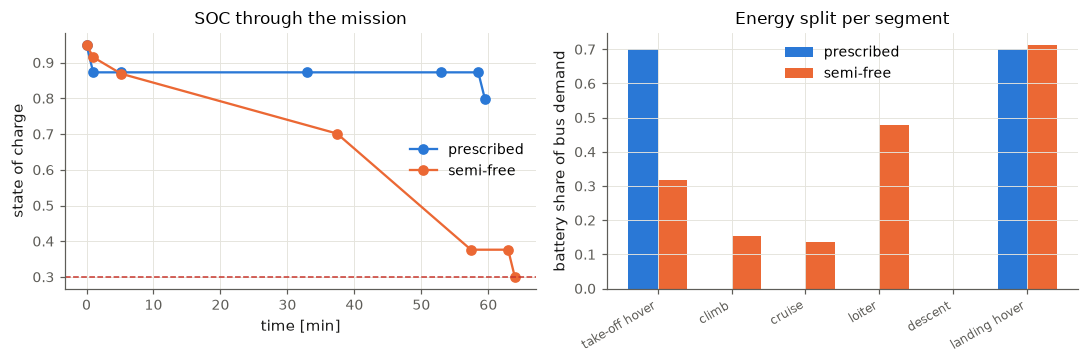

PASS  the semi-free mission ends on the SOC floor


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for (name, r), color in zip(results.items(), (blue, orange)):
    times = onp.concatenate([[0], onp.cumsum([seg[1] for seg in r.segments])]) / 60
    socs = [soc_take_off] + [seg[4] for seg in r.segments]
    axes[0].plot(times, socs, "o-", color=color, label=name)
    axes[1].bar(onp.arange(len(r.segments)) + (0.2 if name == "semi-free" else -0.2), [seg[5] for seg in r.segments], width=0.4,
                color=color, label=name)
axes[0].axhline(soc_minimum, color=red, ls="--", lw=1)
axes[0].set(xlabel="time [min]", ylabel="state of charge", title="SOC through the mission")
axes[1].set(xticks=range(len(results["prescribed"].segments)), ylabel="battery share of bus demand", title="Energy split per segment")
axes[1].set_xticklabels([seg[0] for seg in results["prescribed"].segments], rotation=30, ha="right", fontsize=8)
axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.show()
check("the semi-free mission ends on the SOC floor", abs(results["semi-free"].soc_end - soc_minimum) < 1e-6)

This is the energy-management problem of a hybrid aircraft, solved as part of sizing: no rule-based controller, no outer loop. A negative share
(`hybridization_electric_min < 0`, used by the Halo) would also let the generators **recharge** the pack in flight.

## 5. Sub-segments, the equivalent circuit and thermal history

- `subsegments`: an integer for every segment or a tuple with one count per segment; each segment becomes that many equal-duration points (labels
  `"cruise 2/4"`), so OCV and resistance can follow SOC within a long segment. The Halo uses `(1, 1, 4, 1, 1, 1)`: four points in cruise.
- With an `EquivalentCircuitBattery`, the battery owns the SOC update, the RC voltages propagate from rest (`polarization_start="rest"`) and every point
  checks its end voltage against the cell cutoff (tutorial 07).
- `thermal_start`: `"steady"` gives each point its steady state (continuous ratings, no history); `"coolant"` starts every thermal component at the
  coolant temperature and propagates; a dict continues an earlier history (the Halo's failure hovers start from the end of the take-off hover).

The test below confirms that splitting a segment does not change a constant-battery mission's answer much (the physics is the same at each sub-point,
only the mass falls a bit between them):

In [7]:
from examples.aircraft_mass_closure import build_reference_aircraft
from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.vehicle.condition import StructuralDesignCondition

def fixed_mass_mission(subsegments):
    opti = asb.Opti()
    aircraft = build_reference_aircraft(3.234, 300.0, area_horizontal_tail_m2=2.16, area_vertical_tail_m2=1.92)
    flown = build_mission(opti, aircraft, SimpleAerodynamics(), reference_mission(), 1650.0, soc_take_off, subsegments=subsegments)
    opti.subject_to([m.value >= 0 for m in flown.margins])
    opti.minimize(flown.mass_fuel_burnt_kg)
    s = opti.solve(verbose=False)
    return s.value(flown.mass_fuel_burnt_kg), [r.point.condition.label for r in flown.segments[2].subsegments] or [flown.segments[2].point.condition.label]

fuel_1, labels_1 = fixed_mass_mission(1)
fuel_4, labels_4 = fixed_mass_mission((1, 1, 4, 1, 1, 1))
print(f"one point per segment: {fuel_1:.4f} kg;  four cruise points: {fuel_4:.4f} kg;  cruise labels {labels_4}")
check("sub-segmenting cruise changes fuel by under 0.5 % (mass falls slightly between sub-points)", abs(fuel_4 / fuel_1 - 1) < 0.005)

one point per segment: 30.0322 kg;  four cruise points: 29.9936 kg;  cruise labels ['cruise 1/4', 'cruise 2/4', 'cruise 3/4', 'cruise 4/4']
PASS  sub-segmenting cruise changes fuel by under 0.5 % (mass falls slightly between sub-points)


## 6. The Halo mission

`halo_mission(requirements, velocity_cruise_m_s=None, velocity_loiter_m_s=None)` builds the design mission: take-off hover, climb to 10,000 ft,
cruise (the range less the climb and descent ground distance), a 20-minute reserve loiter, descent, landing hover. Cruise and loiter speeds are
variables in the sizing, every split is free, generators may recharge (`hybridization_electric_min = -1`), and the 30 % reserve SOC is held at every
segment end. The engine-out and failure hovers start from that reserve. Its profile on the fast reference of tutorial 00:

In [8]:
from examples.halo_sizing import halo_mission, HaloRequirements, solve_halo_sizing, requirements_tier16, assumptions_tier16
for segment in halo_mission(HaloRequirements(), velocity_cruise_m_s=85.0, velocity_loiter_m_s=60.0).segments:
    print(f"   {segment.label:<16}{type(segment).__name__:<15}{segment.duration_s() / 60:6.1f} min")
result = solve_halo_sizing(requirements_tier16, assumptions_tier16)
print(f"\nsized: cruise {result.velocity_cruise_m_s / u.knot:.0f} kt, loiter {result.velocity_loiter_m_s / u.knot:.0f} kt")
print(f"{'segment':<16}{'min':>6}{'fuel kg':>9}{'SOC end':>9}")
for s_ in result.segments:
    print(f"{s_['label']:<16}{s_['duration_s'] / 60:6.1f}{s_['fuel_kg']:9.1f}{s_['soc_end']:9.3f}")

   take-off hover  HoverSegment      1.0 min
   climb           ClimbSegment      8.5 min
   cruise          CruiseSegment   144.1 min
   reserve loiter  LoiterSegment    20.0 min
   descent         DescentSegment   10.2 min
   landing hover   HoverSegment      1.0 min



sized: cruise 156 kt, loiter 129 kt
segment            min  fuel kg  SOC end
take-off hover     1.0      6.8    0.855
climb              8.5     60.3    0.950
cruise           152.3    745.7    0.300
reserve loiter    20.0     83.3    0.300
descent           10.2     39.4    0.459
landing hover      1.0      4.6    0.300


Read the SOC column: the hover draws the pack down; **the generators recharge it in the climb** (SOC rises to the 0.95 cap); cruise spends it to
the 0.30 floor; the descent recharges again (spare turbine power while descending); the landing hover spends it back to the floor. That pattern
was not prescribed anywhere: it is the optimal energy allocation for minimum take-off mass, with the reserve held at every segment end.

In [9]:
socs = [s_["soc_end"] for s_ in result.segments]
check("the Halo's generators recharge the pack in flight (SOC rises in some segment)", any(b > a + 1e-3 for a, b in zip(socs, socs[1:])))

PASS  the Halo's generators recharge the pack in flight (SOC rises in some segment)


## Summary

- Segments map to flight conditions plus durations; any speed, altitude, distance or split may be a variable.
- `build_mission` chains points by explicit substitution: mass falls by fuel burnt, SOC by chemical energy (or coulomb counting), RC voltages and temperatures
  propagate; the SOC window holds at every segment end.
- Energy allocation is a set of design variables in the same problem: the optimizer spends the battery where it saves the most.
- The caller adds fuel sufficiency, final SOC and closure.

## Check yourself

<details><summary>1. Why hold the SOC floor at every segment end rather than only at landing?</summary>

Otherwise the optimizer could dip the pack below the reserve mid-mission and recharge it later. The reserve exists for a failure that could happen at any time, so it must be available throughout (`soc_floor_every_segment` in the Halo).
</details>

<details><summary>2. The cruise speed is a variable. What makes its optimum finite?</summary>

Faster cruise shortens the duration but raises drag power (roughly $V^3$); slower cruise lowers power but lengthens the time and raises induced drag. Fuel burnt has a minimum in between, shifted by the turbogenerator's part-power efficiency and the rotor's propulsive efficiency.
</details>

In [10]:
check_summary()

5 of 5 checks passed
